In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO

In [4]:
site = "HC"
ctsm_file = "C:/Users/madel/Code/GeoNorth/CTSM_data/run_1/merged_files/HC_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
var_soilt = df["TSOI"]
var_soilt

C:\Users\madel\AppData\Local\Temp\ipykernel_12728\4105822762.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [5]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_t"}, inplace=True)
    return obs

In [6]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = f"{site}_obs/soil_temp"
observe = {}

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.update({f"{filename}":df})

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'HC_obs/soil_temp'

In [7]:
for x in observe:
  print(observe[x]) 

C:\Users\madel\AppData\Local\Temp\ipykernel_12728\1826080259.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


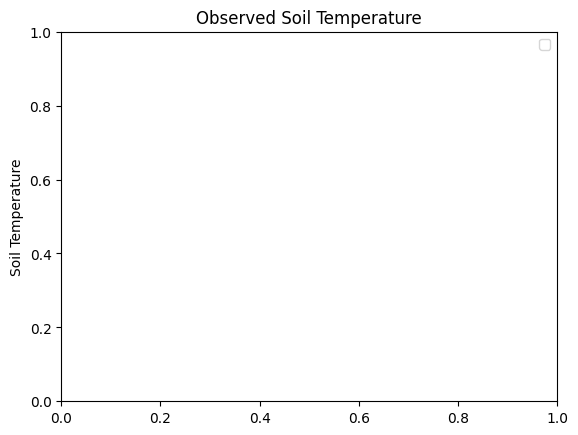

In [8]:
for data in observe:  
    plt.plot(observe[data]["time"], observe[data]["obs_t"], label=f"{data}")
plt.ylabel("Soil Temperature")
plt.title("Observed Soil Temperature")
plt.legend()
plt.show()

In [9]:
var_soilt

<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [10]:
# obs_clean = {}
# for n in observe:
#     observe[n]["obs_t"] = observe[n]["obs_t"]
#     observe[n] = observe[n][observe[n]["obs_depth"] >= 0]
#     observe[n]["time"] = pd.to_datetime(observe[n]["time"])
#     obs_clean.update({f"{n}":observe[n]})
    

# for x in obs_clean:
#   print(obs_clean[x]) 

In [11]:
for x in observe:
    print(x)

## Interpolation

defining the interpolation function here

In [12]:
ds = xr.open_dataset(ctsm_file, engine="netcdf4")

def interpolate_to_depth(ds, var, target_depth, depth_dim="levgrnd"):
    sm = ds[var].squeeze()
    depths = ds[depth_dim].values.flatten()
    
    # Convert CFTime to pandas datetime here, once
    cf_times = ds.indexes['time']
    time = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" 
                           for t in cf_times])
    
    # Interpolate
    idx = int(np.searchsorted(depths, target_depth, side="right") - 1)
    idx = int(np.clip(idx, 0, len(depths) - 2))
    z0, z1 = depths[idx], depths[idx + 1]
    w = (target_depth - z0) / (z1 - z0)
    sm_interp = ((1 - w) * sm.values[:, idx] + w * sm.values[:, idx + 1]).flatten()
    
    return xr.DataArray(
        sm_interp,
        coords={"time": time},
        dims=["time"],
        attrs={"units": ds[var].attrs.get("units", ""), 
               "long_name": f"{var} interpolated at {target_depth}m"},
    )


C:\Users\madel\AppData\Local\Temp\ipykernel_12728\1279570558.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(ctsm_file, engine="netcdf4")


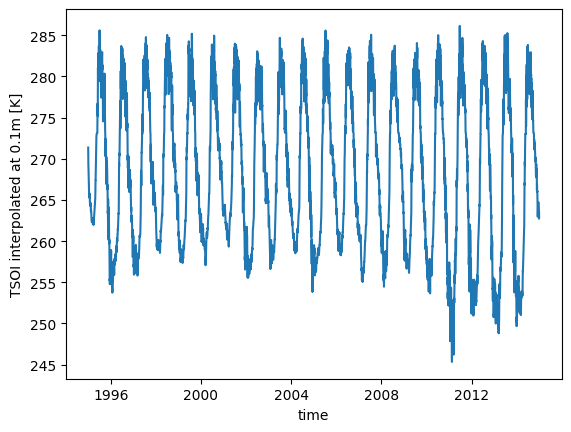

In [13]:
# Usage
da_interp = interpolate_to_depth(ds, "TSOI", target_depth=0.10)
  
da_interp.plot()

## Plotting

defining the plotting funtion for it to be run a few times

In [88]:
def final_plot(obs_concat, sim, site, deep):
    # Convert pandas → xarray
    obs = obs_concat.set_index("time").to_xarray()

    # Resample observational data to daily frequency
    obs_daily = obs.resample(time="1D").mean()

    # Convert K → °C for plotting
    sim_C = sim - 273.15

    plt.figure(figsize=(14,6))

    # Observed (daily)
    plt.plot(
        obs_daily["time"].values,
        obs_daily["obs_t"].values,
        label="Observed Soil Temperature (C)",
        linewidth=2
    )

    # Simulated
    plt.plot(
        sim_C["time"].values,
        sim_C.values,
        label="Simulated Soil Temperature (C)",
        linewidth=2
    )

    plt.xlabel("Time")
    plt.ylabel("Soil Temperature (C)")
    plt.title(f"Soil Temperature at Havipak Creek - {deep}cm")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"0_final_images/{site}_soil_temperature_{deep}.png")
    plt.show()

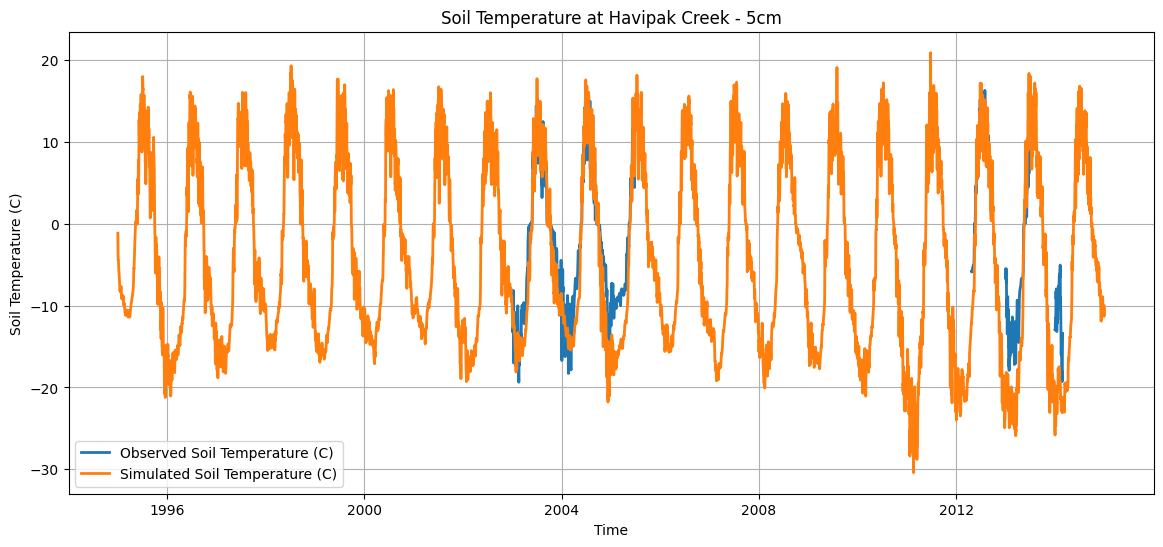

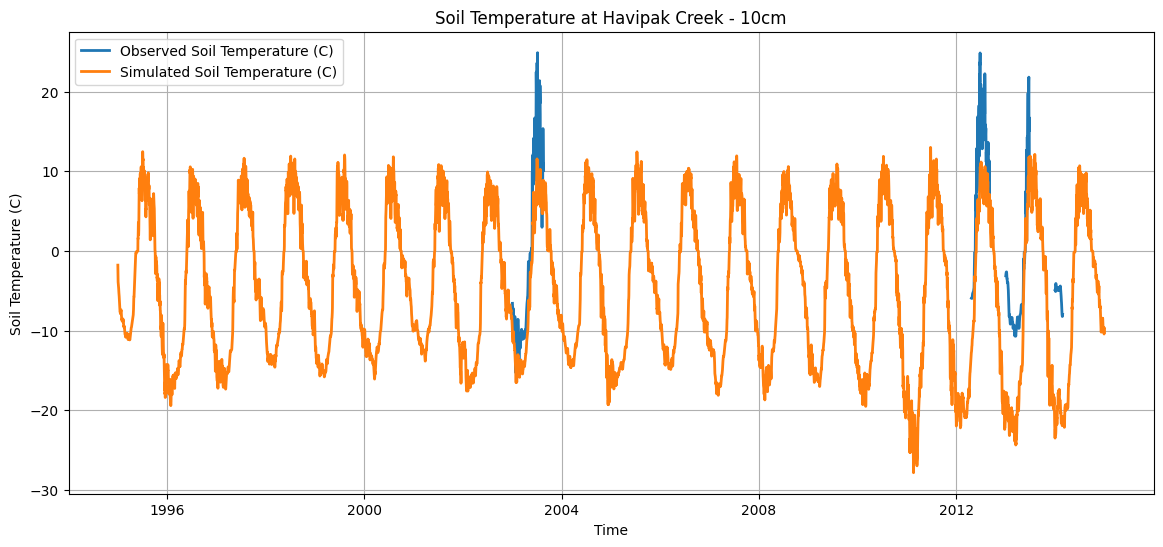

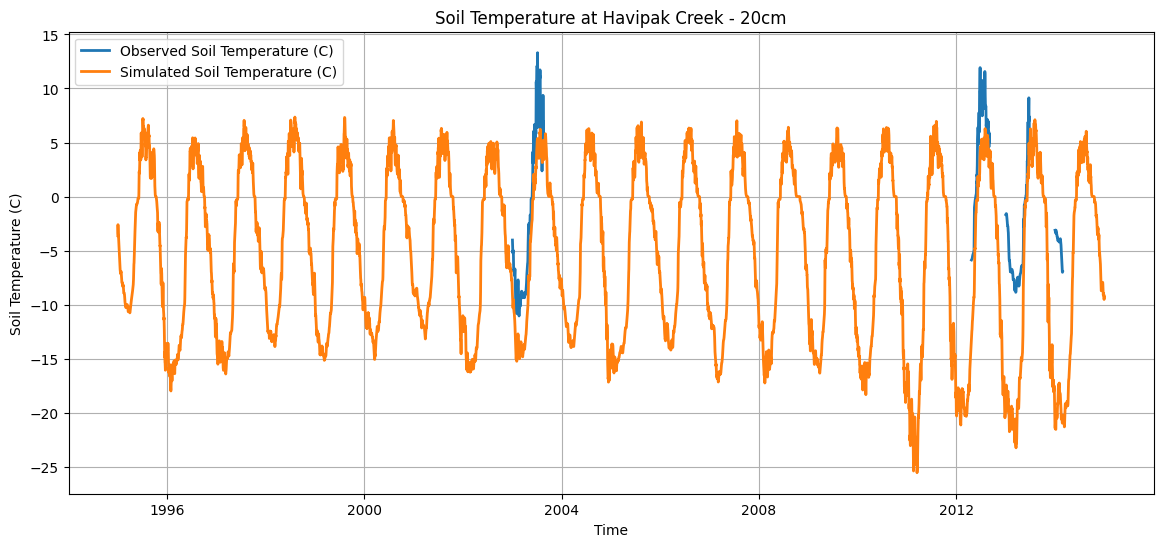

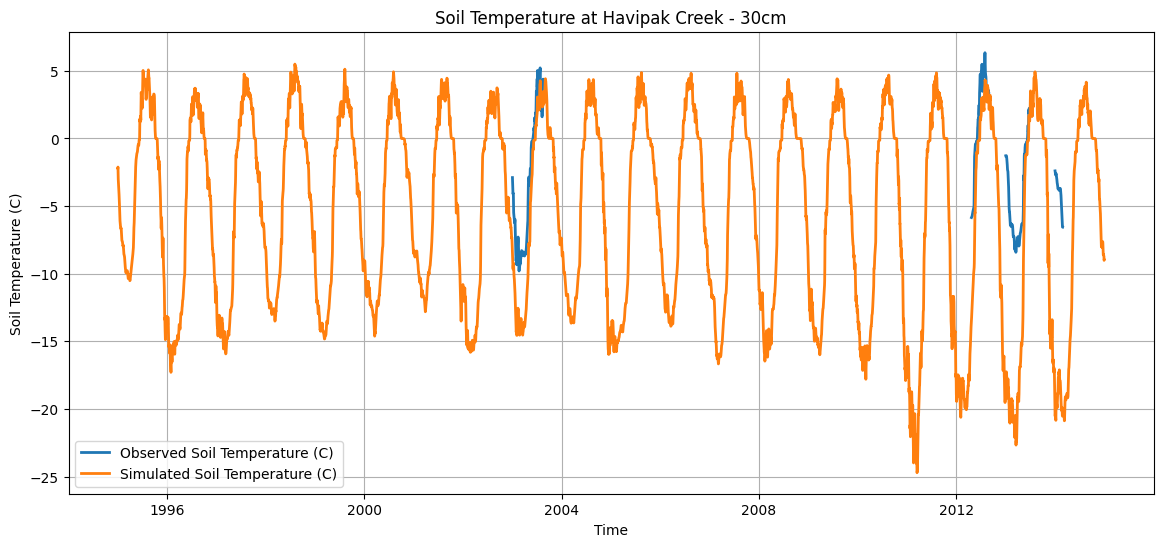

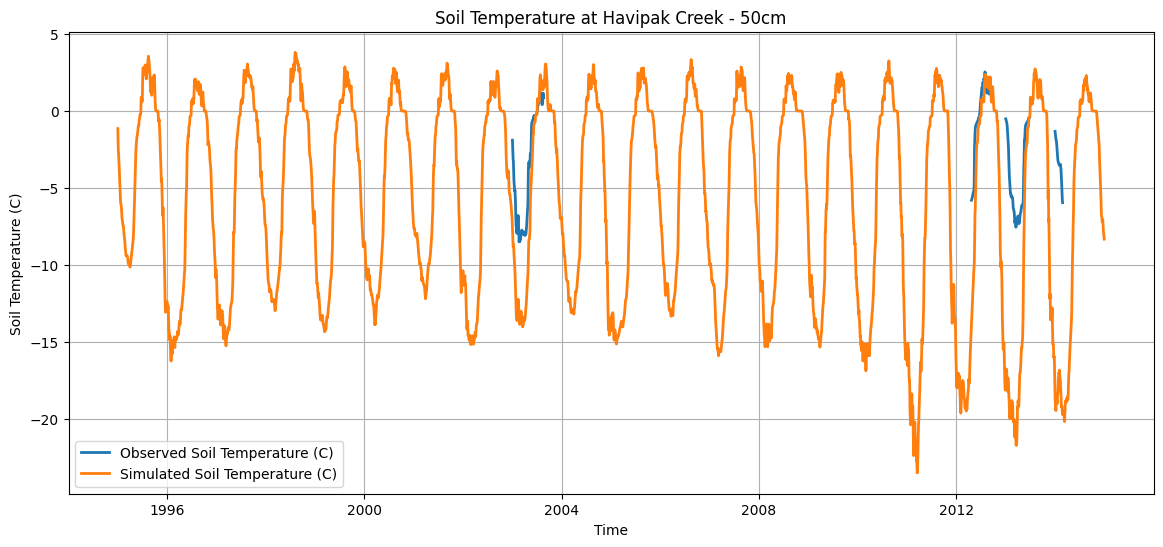

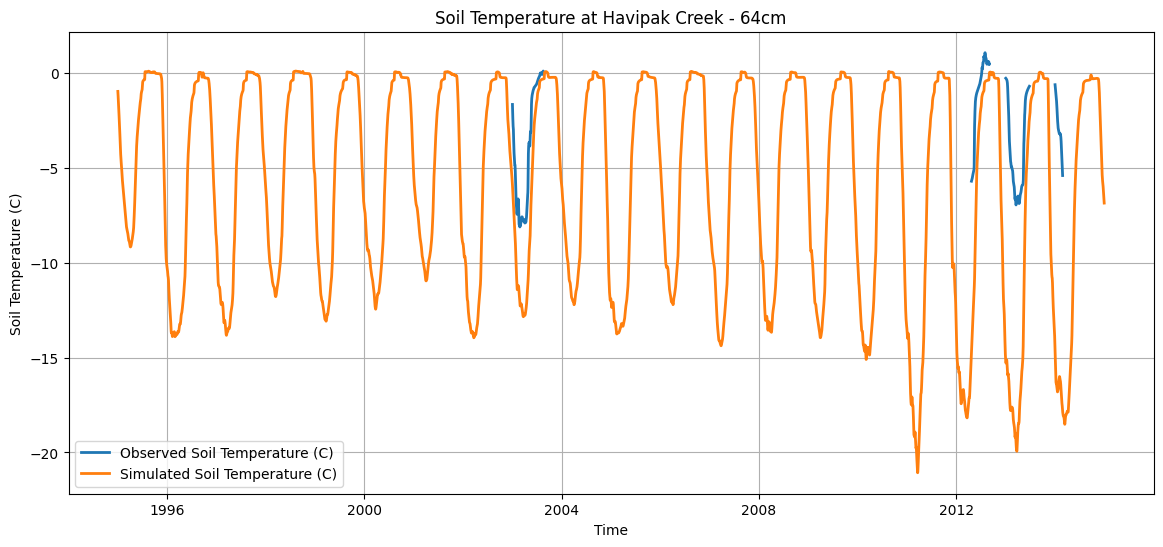

In [89]:
final_plot(observe[f"{site}_soil_temp_5.txt"], interpolate_to_depth(ds, "TSOI", target_depth=0.035), site, 5)
final_plot(observe[f"{site}_soil_temp_10.txt"], interpolate_to_depth(ds, "TSOI", target_depth=0.10), site, 10)
final_plot(observe[f"{site}_soil_temp_20.txt"], interpolate_to_depth(ds, "TSOI", target_depth=0.20), site, 20)
final_plot(observe[f"{site}_soil_temp_30.txt"], interpolate_to_depth(ds, "TSOI", target_depth=0.30), site, 30)
final_plot(observe[f"{site}_soil_temp_50.txt"], interpolate_to_depth(ds, "TSOI", target_depth=0.50), site, 50)
final_plot(observe[f"{site}_soil_temp_64.txt"], interpolate_to_depth(ds, "TSOI", target_depth=1.04), site, 64)

## Soil Temperature Profiles for August

August timesteps: 620


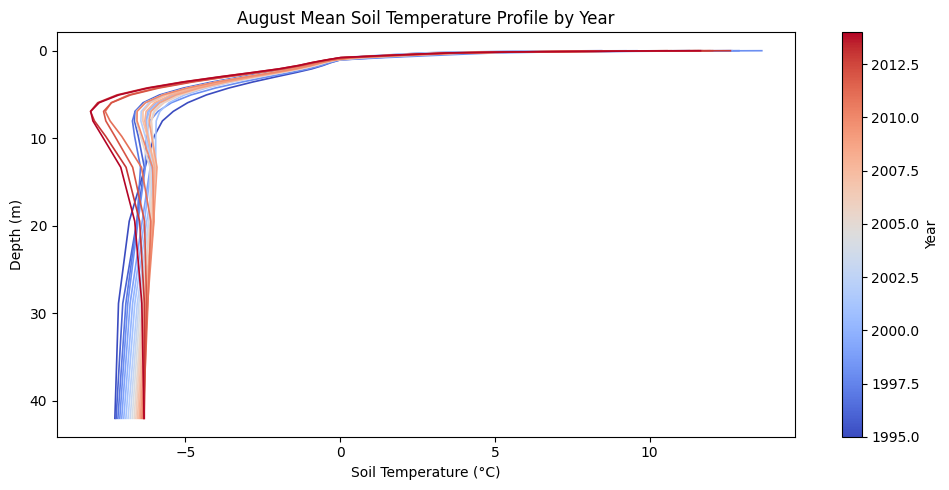

In [90]:
# Load soil temperature — same structure as H2OSOI
st = ds["TSOI"].squeeze()          # shape: (time, levgrnd)
depths = ds["levgrnd"].values.flatten()

# Convert time once
cf_times = ds.indexes['time']
time_pd = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" for t in cf_times])

# Build a DataArray with pandas time index
da_st = xr.DataArray(
    st.values,
    coords={"time": time_pd, "depth": depths},
    dims=["time", "depth"],
    attrs={"units": ds["TSOI"].attrs.get("units", "K"),
           "long_name": "Soil temperature"},
)

# Convert K to °C if needed
if da_st.attrs["units"] == "K":
    da_st = da_st - 273.15
    da_st.attrs["units"] = "°C"

# Filter to August only
da_aug = da_st.sel(time=da_st["time"].dt.month == 8)  # all Augusts across 20 years
print(f"August timesteps: {len(da_aug.time)}")         # should be ~20 x 31 = 620 days

#Individual August profiles, one line per year
years = np.unique(da_aug["time"].dt.year.values)
cmap  = cm.coolwarm(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, year in enumerate(years):
    aug_year = da_aug.sel(time=da_aug["time"].dt.year == year).mean(dim="time")
    ax.plot(aug_year.values, depths, color=cmap[i], linewidth=1.2, label=str(year))

ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("August Mean Soil Temperature Profile by Year")
ax.invert_yaxis()
sm_cbar = plt.cm.ScalarMappable(cmap="coolwarm",
                                 norm=plt.Normalize(years.min(), years.max()))
plt.colorbar(sm_cbar, ax=ax, label="Year")
plt.tight_layout()
plt.show()


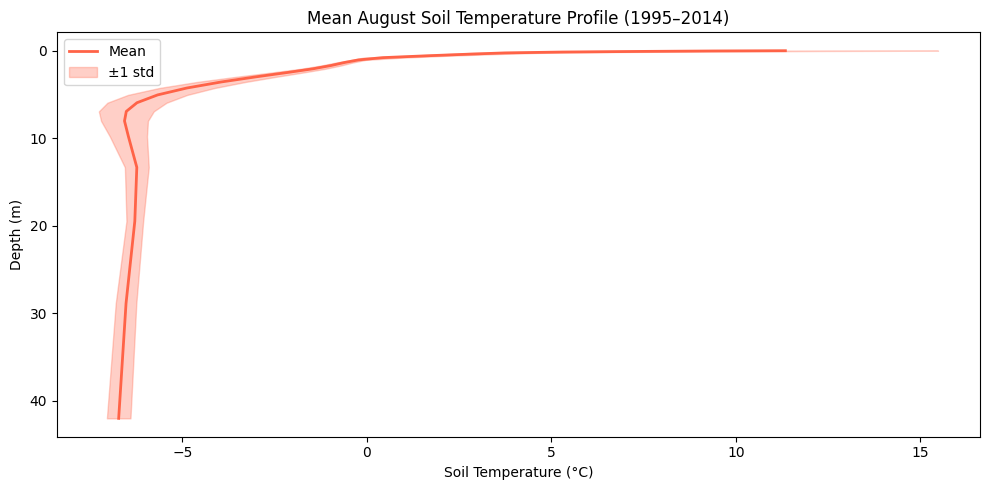

In [91]:
# --- Plot 1: Mean August soil temperature profile ---
aug_mean = da_aug.mean(dim="time")
aug_std  = da_aug.std(dim="time")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(aug_mean.values, depths, color="tomato", linewidth=2, label="Mean")
ax.fill_betweenx(
    depths,
    aug_mean.values - aug_std.values,
    aug_mean.values + aug_std.values,
    alpha=0.3, color="tomato", label="±1 std"
)
ax.set_xlabel("Soil Temperature (°C)")
ax.set_ylabel("Depth (m)")
ax.set_title("Mean August Soil Temperature Profile (1995–2014)")
ax.invert_yaxis()   # surface at top
ax.legend()
plt.tight_layout()
plt.show()

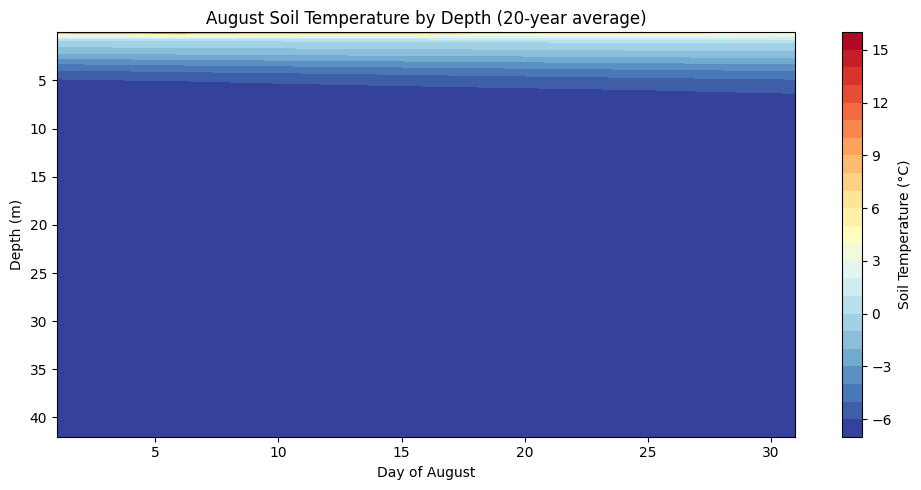

In [92]:

# --- Plot 3: Heatmap — depth vs day-of-August, averaged across all years ---
da_aug_copy = da_aug.assign_coords(doy=("time", da_aug["time"].dt.day.values))
aug_by_day  = da_aug_copy.groupby("doy").mean()   # mean across all 20 Augusts per day

fig, ax = plt.subplots(figsize=(10, 5))
c = ax.contourf(
    aug_by_day["doy"].values,
    depths,
    aug_by_day.values.T,
    levels=25, cmap="RdYlBu_r"
)
plt.colorbar(c, ax=ax, label="Soil Temperature (°C)")
ax.set_xlabel("Day of August")
ax.set_ylabel("Depth (m)")
ax.set_title("August Soil Temperature by Depth (20-year average)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## NOTE

not sure if in this function, I need to be averaging over all AUgust for CTSM, or if I need the dat ranges to match

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_august_soil_temp_profile(obs_files: dict, da_aug, depths):
    """
    Plot mean August soil temperature profile comparing observations vs CTSM output.

    Parameters
    ----------
    obs_files : dict
        Keys are filenames like 'TVC_soil_temp_50.txt', values are DataFrames
        with columns [time, temp_c] (first col = time, second = temp).
    da_aug : xarray.DataArray
        CTSM August soil temperature data with dim 'time'.
    depths : array-like
        Depth values (in meters) for the CTSM soil layers.
    """

    # --- Parse observed data ---
    obs_records = []

    for filename, df in obs_files.items():
        depth_cm = float(filename.replace("HC_soil_temp_", "").replace(".txt", ""))
        depth_m = depth_cm / 100.0

        df = df.copy()
        df.columns = ["time", "temp_c"]
        df["time"] = pd.to_datetime(df["time"])

        aug_df = df[df["time"].dt.month == 8]

        if aug_df.empty:
            print(f"Warning: no August data found in {filename}")
            continue

        obs_records.append({
            "depth_m":   depth_m,
            "mean_temp": aug_df["temp_c"].mean(),
            "std_temp":  aug_df["temp_c"].std(),
            "time_min":  df["time"].min(),
            "time_max":  df["time"].max(),
        })

    obs_df = pd.DataFrame(obs_records).sort_values("depth_m").reset_index(drop=True)

    # --- Compute obs depth and time range ---
    depth_min = obs_df["depth_m"].min()
    depth_max = obs_df["depth_m"].max() + 0.25
    time_min  = obs_df["time_min"].min()
    time_max  = obs_df["time_max"].max()

    print(f"Restricting CTSM to depths {depth_min}–{depth_max} m "
          f"and time {time_min.date()}–{time_max.date()}")

    # --- Mask CTSM by depth ---
    depths = np.array(depths)
    depth_mask      = (depths >= depth_min) & (depths <= depth_max)
    depths_masked   = depths[depth_mask]

    # --- Mask CTSM by time ---
    ctsm_times = pd.to_datetime(da_aug["time"].values).tz_localize(None)
    time_min   = time_min.tz_localize(None) if time_min.tzinfo else time_min
    time_max   = time_max.tz_localize(None) if time_max.tzinfo else time_max

    time_mask     = (ctsm_times >= time_min) & (ctsm_times <= time_max)
    da_aug_masked = da_aug.isel(time=time_mask)

    # --- Compute CTSM mean/std over masked time, then mask depth ---
    aug_mean = da_aug_masked.mean(dim="time").values[depth_mask]
    aug_std  = da_aug_masked.std(dim="time").values[depth_mask]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6, 6))

    # CTSM
    ax.plot(aug_mean, depths_masked,
            color="tomato", linewidth=2, label="CTSM Mean")
    # ax.fill_betweenx(depths_masked,
    #                  aug_mean - aug_std,
    #                  aug_mean + aug_std,
    #                  alpha=0.3, color="tomato", label="CTSM ±1 std")

    # Observed
    ax.plot(obs_df["mean_temp"], obs_df["depth_m"],
            color="steelblue", linewidth=2, marker="o", label="Observed Mean")
    # ax.fill_betweenx(obs_df["depth_m"],
    #                  obs_df["mean_temp"] - obs_df["std_temp"],
    #                  obs_df["mean_temp"] + obs_df["std_temp"],
    #                  alpha=0.3, color="steelblue", label="Obs ±1 std")

    ax.set_xlabel("Soil Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("August Soil Temperature Profile at Havipak Creek")
    ax.set_ylim(0, depth_max)
    ax.set_xlim(-2,20)
    ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"0_final_images/HC_soil_temp_profile.png")
    plt.show()

Restricting CTSM to depths 0.05–0.89 m and time 2003-01-01–2014-02-26


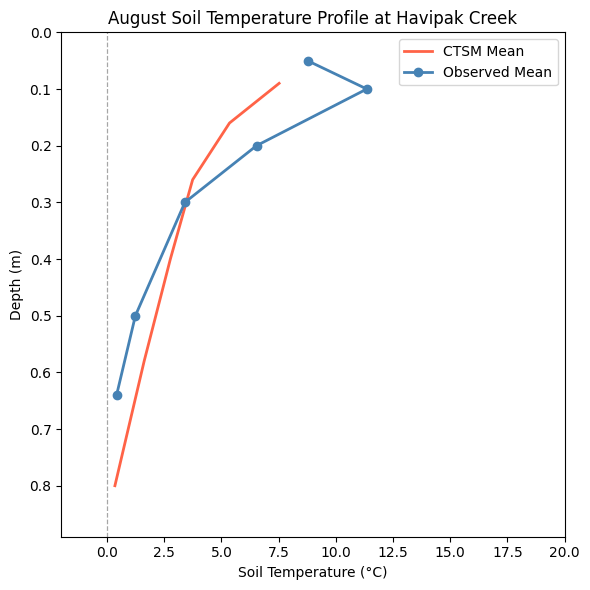

In [96]:
plot_august_soil_temp_profile(observe, da_aug, depths)